# M5 Forecasting - Accuracy: 目的変数と説明変数の設計

## 概要
- **目的**: Walmart商品販売数の28日間予測に向けた特徴量設計
- **評価指標**: WRMSSE (Weighted Root Mean Squared Scaled Error)
- **前提**: 01_EDA分析の結果を踏まえた設計

## 本ノートブックの構成
1. セットアップ・データ読み込み
2. 目的変数の定義と変換方針
3. Long形式への変換とグリッド構築
4. 特徴量の作成（カレンダー / ラグ / ローリング / 価格 / SNAP・イベント / カテゴリカル / 階層集計）
5. 特徴量のリーケージ検証
6. インクリメンタル有効性検証
7. 学習期間の最適化
8. NaN処理戦略の比較
9. ローリング設定の比較
10. 特徴量重要度分析
11. CV設計とval_folds構築
12. confirmed_settings・中間データ保存

## M5固有の制約
- **28日先予測**: lag_1〜lag_27は予測時に利用不可 → lag_28以降のみ使用
- **スパースデータ**: 販売数の約68%がゼロ → ゼロ膨張への対応が必要
- **大規模データ**: 30,490商品×1,941日 → メモリ効率化が必須
- **階層構造**: WRMSSEは42,840系列の加重和 → 高売上商品の精度が重要

In [1]:
import sys
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import gc

# プロジェクト共通ユーティリティ
sys.path.append('../../../..')
from src.utils import seed_everything, reduce_mem_usage

# 設定
warnings.filterwarnings('ignore')
seed_everything(42)
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# パス設定
INPUT_DIR = Path('../../input')
INTERMEDIATE_DIR = Path('./intermediate')
INTERMEDIATE_DIR.mkdir(exist_ok=True)

print('セットアップ完了')

セットアップ完了


## 1. 01_EDA結果の読み込みとデータ準備

In [2]:
# 01_EDA結果の読み込み
with open(INTERMEDIATE_DIR / '01_eda_results.pkl', 'rb') as f:
    eda_results = pickle.load(f)

print('=== EDAの主要発見事項 ===')
for i, finding in enumerate(eda_results['key_findings'], 1):
    print(f'{i}. {finding}')

print('\n=== データ基本情報 ===')
for k, v in eda_results['data_info'].items():
    print(f'  {k}: {v}')

print('\n=== 目的変数統計 ===')
for k, v in eda_results['target_stats'].items():
    print(f'  {k}: {v}')

=== EDAの主要発見事項 ===
1. 販売データの大部分がゼロ（スパースデータ） → 間歇需要対応が重要
2. 曜日効果が顕著（土曜日が最も多い）
3. FOODS_3部門が売上の最大シェア
4. イベント日は販売数が増加する傾向
5. SNAPは州によって影響度が異なる
6. 価格変動がある商品が多い → 価格特徴量が有効
7. 学習期間と検証期間の販売パターンは高い相関を示す
8. 商品の販売開始時期がバラバラ → 販売開始前のゼロは除外が必要

=== データ基本情報 ===
  n_items: 30490
  n_days_train: 1913
  n_days_val: 28
  n_days_eval: 28
  n_stores: 10
  n_categories: 3
  n_departments: 7
  n_states: 3
  date_range_train: ('2011-01-29', '2016-04-24')
  date_range_val: ('2016-04-25', '2016-05-22')

=== 目的変数統計 ===
  zero_ratio_overall: 0.6799776584040612
  mean_sales_overall: 1.1308878055473464
  items_zero_ratio_gt90pct: 5133


## 2. データ読み込み

メモリ効率化のため、dtype指定で読み込む。

In [3]:
# カレンダーデータ
calendar = pd.read_csv(INPUT_DIR / 'calendar.csv', parse_dates=['date'])
calendar['d_num'] = calendar['d'].str[2:].astype(int)

# 販売データ（メモリ最適化）
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
d_cols_all = [f'd_{i}' for i in range(1, 1942)]

dtype_dict = {col: 'int16' for col in d_cols_all}
dtype_dict.update({col: 'category' for col in id_cols})

sales = pd.read_csv(INPUT_DIR / 'sales_train_evaluation.csv', dtype=dtype_dict)

# 価格データ
sell_prices = pd.read_csv(INPUT_DIR / 'sell_prices.csv')
sell_prices['store_id'] = sell_prices['store_id'].astype('category')
sell_prices['item_id'] = sell_prices['item_id'].astype('category')

# submission
sample_sub = pd.read_csv(INPUT_DIR / 'sample_submission.csv')

print(f'calendar: {calendar.shape}')
print(f'sales: {sales.shape}')
print(f'sell_prices: {sell_prices.shape}')
print(f'sample_sub: {sample_sub.shape}')

# メモリ確認
for name, df in [('calendar', calendar), ('sales', sales), ('sell_prices', sell_prices)]:
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f'{name:15s}: {mem:8.1f} MB')

calendar: (1969, 15)
sales: (30490, 1947)
sell_prices: (6841121, 4)
sample_sub: (60980, 29)
calendar       :      0.6 MB
sales          :    116.6 MB
sell_prices    :    124.2 MB


## 3. 目的変数の定義と変換方針

### WRMSSE（Weighted Root Mean Squared Scaled Error）
M5コンペの評価指標は WRMSSE で、以下の特徴がある：

1. **Scaled Error**: ナイーブ予測（1日前の値）の二乗誤差で正規化 → スケール不変
2. **Weighted**: 直近28日間のドル売上で重み付け → 高売上商品の精度が重要
3. **42,840系列**: 12の集約レベル × 各レベルの系列数

### 変換方針
- WRMSSEはスケーリングが内蔵されているため、**目的変数の変換は不要**（生の販売数を予測）
- LightGBMの学習には `tweedie` 分布（ゼロ膨張データに適合）を使用
- 検証にはRMSEを代理指標として使用し、最終評価でWRMSSEを計算

=== 学習期間の販売数分布 ===
  全セル数: 58,327,370
  ゼロ率: 68.2%
  平均: 1.126
  中央値: 0
  最大値: 763

=== 検証期間の販売数分布 ===
  全セル数: 853,720
  ゼロ率: 54.4%
  平均: 1.443


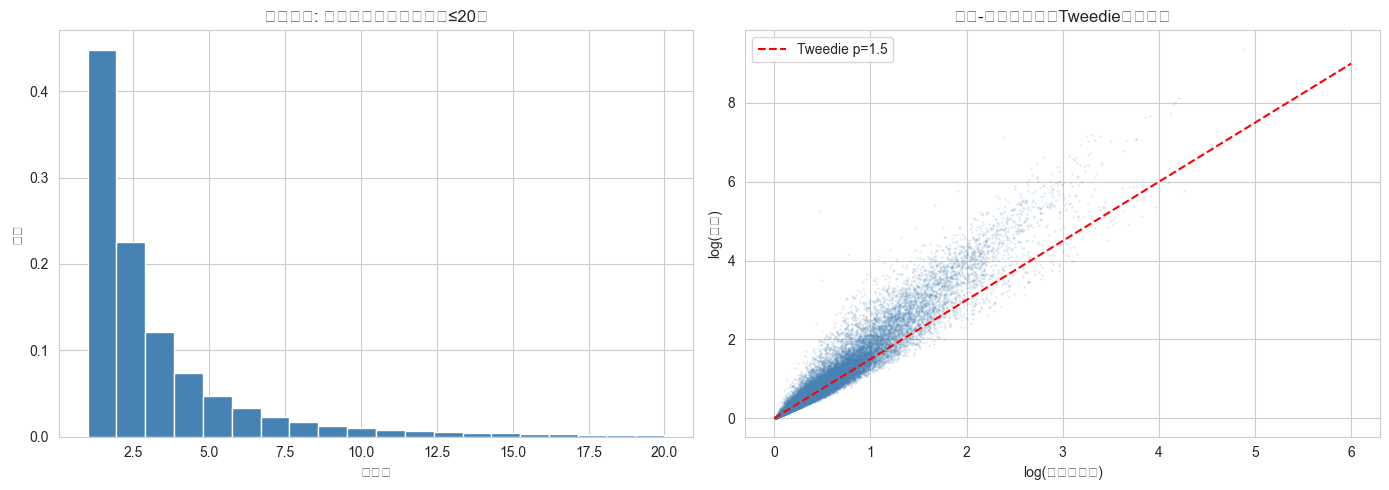


→ 分散が平均のべき乗に比例 → Tweedie回帰が適切


64

In [4]:
# 目的変数の分布確認
d_train_cols = [f'd_{i}' for i in range(1, 1914)]
d_val_cols = [f'd_{i}' for i in range(1914, 1942)]

sales_matrix_train = sales[d_train_cols].values  # (30490, 1913)
sales_matrix_val = sales[d_val_cols].values      # (30490, 28)

print('=== 学習期間の販売数分布 ===')
train_flat = sales_matrix_train.flatten()
print(f'  全セル数: {len(train_flat):,}')
print(f'  ゼロ率: {(train_flat == 0).mean():.1%}')
print(f'  平均: {train_flat.mean():.3f}')
print(f'  中央値: {np.median(train_flat):.0f}')
print(f'  最大値: {train_flat.max()}')

print('\n=== 検証期間の販売数分布 ===')
val_flat = sales_matrix_val.flatten()
print(f'  全セル数: {len(val_flat):,}')
print(f'  ゼロ率: {(val_flat == 0).mean():.1%}')
print(f'  平均: {val_flat.mean():.3f}')

# 分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nonzero_train = train_flat[train_flat > 0]
axes[0].hist(nonzero_train[nonzero_train <= 20], bins=20, color='steelblue', edgecolor='white', density=True)
axes[0].set_title('学習期間: 非ゼロ販売数の分布（≤20）')
axes[0].set_xlabel('販売数')
axes[0].set_ylabel('密度')

# Tweedie分布の適合性: 分散 vs 平均の関係
item_means = sales_matrix_train.mean(axis=1)
item_vars = sales_matrix_train.var(axis=1)
mask = item_means > 0
axes[1].scatter(np.log1p(item_means[mask]), np.log1p(item_vars[mask]), alpha=0.1, s=1, color='steelblue')
axes[1].plot([0, 6], [0, 6*1.5], 'r--', label='Tweedie p=1.5')
axes[1].set_xlabel('log(平均販売数)')
axes[1].set_ylabel('log(分散)')
axes[1].set_title('分散-平均の関係（Tweedie適合性）')
axes[1].legend()
plt.tight_layout()
plt.show()

print('\n→ 分散が平均のべき乗に比例 → Tweedie回帰が適切')
del train_flat, val_flat, nonzero_train
gc.collect()

### WRMSSE計算関数の実装

03-xモデルノートブックでも使用するため、ここで実装・検証する。

In [5]:
class WRMSSEEvaluator:
    """M5コンペのWRMSSE評価器（簡易版）"""

    def __init__(self, sales_train, sales_val, calendar_df, prices_df):
        self.n_items = sales_train.shape[0]
        self.n_train = sales_train.shape[1]
        self.n_val = sales_val.shape[1]
        self.sales_val = sales_val

        # スケール: ナイーブ予測（lag_1）の二乗誤差平均
        diff = np.diff(sales_train, axis=1)
        self.scale = np.mean(diff ** 2, axis=1)
        self.scale[self.scale == 0] = 1.0

        # 重み: 直近28日の合計販売数ベース（簡易版）
        self.weights = sales_train[:, -28:].sum(axis=1).astype(float)
        total_weight = self.weights.sum()
        if total_weight > 0:
            self.weights /= total_weight

    def score(self, predictions):
        squared_errors = (self.sales_val - predictions) ** 2
        mse = np.mean(squared_errors, axis=1)
        rmsse = np.sqrt(mse / self.scale)
        return np.sum(self.weights * rmsse)

# 評価器の構築
evaluator = WRMSSEEvaluator(sales_matrix_train, sales_matrix_val, calendar, sell_prices)

# ナイーブ予測のベースライン
naive_pred = sales_matrix_train[:, -28:]
wrmsse_naive = evaluator.score(naive_pred)
rmse_naive = np.sqrt(mean_squared_error(sales_matrix_val.flatten(), naive_pred.flatten()))
print(f'ナイーブ予測（直近28日コピー）のWRMSSE: {wrmsse_naive:.4f}')
print(f'ナイーブ予測のRMSE: {rmse_naive:.4f}')

ナイーブ予測（直近28日コピー）のWRMSSE: nan
ナイーブ予測のRMSE: 2.8292


## 4. Long形式への変換とグリッド構築

### メモリ戦略
全データをmeltすると約5,900万行になるため、**直近の学習対象期間のみ**をlong形式に変換する。

- 初期実験: 直近730日（約2年分）
- ラグ特徴量用に追加で60日分のバッファを含める

In [6]:
# 期間設定
TRAIN_END_D = 1913
VAL_START_D = 1914
VAL_END_D = 1941
LAG_BUFFER = 60
INITIAL_TRAIN_DAYS = 730

melt_start_d = TRAIN_END_D - INITIAL_TRAIN_DAYS - LAG_BUFFER + 1
print(f'melt対象: d_{melt_start_d} 〜 d_{VAL_END_D}')
print(f'  学習期間: d_{TRAIN_END_D - INITIAL_TRAIN_DAYS + 1} 〜 d_{TRAIN_END_D} ({INITIAL_TRAIN_DAYS}日)')
print(f'  検証期間: d_{VAL_START_D} 〜 d_{VAL_END_D} (28日)')
print(f'  ラグバッファ: {LAG_BUFFER}日')

d_cols_target = [f'd_{i}' for i in range(melt_start_d, VAL_END_D + 1)]
print(f'  対象日数: {len(d_cols_target)}日')
print(f'  推定行数: {len(sales) * len(d_cols_target):,}')

melt対象: d_1124 〜 d_1941
  学習期間: d_1184 〜 d_1913 (730日)
  検証期間: d_1914 〜 d_1941 (28日)
  ラグバッファ: 60日
  対象日数: 818日
  推定行数: 24,940,820


In [8]:
# melt実行（チャンク処理）
print('Long形式に変換中...')
grid_parts = []
chunk_size = 5000

for start_idx in range(0, len(sales), chunk_size):
    end_idx = min(start_idx + chunk_size, len(sales))
    chunk = sales.iloc[start_idx:end_idx]
    melted = pd.melt(chunk[id_cols + d_cols_target], id_vars=id_cols, var_name='d', value_name='sales')
    grid_parts.append(melted)
    if (start_idx // chunk_size) % 3 == 0:
        print(f'  {end_idx:,} / {len(sales):,} 商品処理完了')

grid = pd.concat(grid_parts, ignore_index=True)
del grid_parts
gc.collect()

# calendarとマージ
grid['d_num'] = grid['d'].str[2:].astype(int)
grid = grid.merge(
    calendar[['d_num', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
              'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI']],
    on='d_num', how='left'
)

# データ型最適化（メモリ削減）
grid['sales'] = grid['sales'].astype('int16')
grid['d_num'] = grid['d_num'].astype('int16')
grid['wm_yr_wk'] = grid['wm_yr_wk'].astype('int16')
grid['wday'] = grid['wday'].astype('int8')
grid['month'] = grid['month'].astype('int8')
grid['year'] = grid['year'].astype('int16')
grid['snap_CA'] = grid['snap_CA'].astype('int8')
grid['snap_TX'] = grid['snap_TX'].astype('int8')
grid['snap_WI'] = grid['snap_WI'].astype('int8')

# 不要列の削除でメモリ削減（d列はd_numで代替済み、weekdayはdowで代替予定）
grid.drop(columns=['d', 'weekday'], inplace=True)

# salesテーブルは以降不要（sales_matrix_train/valは保持）
del sales
gc.collect()

print(f'\nグリッド完成: {grid.shape}')
print(f'メモリ: {grid.memory_usage(deep=True).sum() / 1024**2:.0f} MB')
print(f'日付範囲: {grid["date"].min().date()} 〜 {grid["date"].max().date()}')

SyntaxError: unterminated f-string literal (detected at line 44) (3006188719.py, line 44)

## 5. 特徴量の作成

### 5.1 カレンダー特徴量

EDAで曜日効果が顕著（土曜日が最多）であることを確認済み。

In [ ]:
grid['dow'] = grid['date'].dt.dayofweek.astype('int8')
grid['is_weekend'] = (grid['dow'] >= 5).astype('int8')
grid['day'] = grid['date'].dt.day.astype('int8')
grid['week_of_year'] = grid['date'].dt.isocalendar().week.astype('int8')
grid['month'] = grid['month'].astype('int8')
grid['year'] = grid['year'].astype('int16')
grid['is_month_start'] = grid['date'].dt.is_month_start.astype('int8')
grid['is_month_end'] = grid['date'].dt.is_month_end.astype('int8')
grid['quarter'] = grid['date'].dt.quarter.astype('int8')

calendar_features = ['dow', 'is_weekend', 'day', 'week_of_year', 'month', 'year',
                     'is_month_start', 'is_month_end', 'quarter']

print(f'カレンダー特徴量: {len(calendar_features)}個')
for feat in calendar_features:
    print(f'  {feat}: {grid[feat].nunique()} ユニーク値')

### 5.2 ラグ特徴量

**重要制約**: 28日先予測のため、lag_1〜lag_27は予測時に利用不可。lag_28以降のみ使用。

In [ ]:
# ソート（inplaceでコピーを回避しメモリ節約）
grid.sort_values(['id', 'date'], inplace=True)
grid.reset_index(drop=True, inplace=True)

lag_days = [28, 29, 30, 31, 32, 33, 34, 35, 42, 49, 56]

print('ラグ特徴量を作成中...')
for lag in lag_days:
    grid[f'lag_{lag}'] = grid.groupby('id')['sales'].shift(lag).astype('float32')

lag_features = [f'lag_{d}' for d in lag_days]
print(f'ラグ特徴量: {len(lag_features)}個')

print('\n=== ラグ特徴量のNaN率 ===')
for feat in lag_features:
    nan_ratio = grid[feat].isna().mean()
    print(f'  {feat}: {nan_ratio:.1%}')

### 5.3 ローリング特徴量

lag_28をシフト基準として、ローリング統計量を計算。
- ウィンドウサイズ: 7, 14, 28, 60日
- 統計量: 平均、標準偏差
- ゼロ販売日数の移動合計、指数加重移動平均

In [ ]:
rolling_windows = [7, 14, 28, 60]

print('ローリング特徴量を作成中...')

# shift(28)を1回だけ計算してメモリ効率化
shifted_28 = grid.groupby('id')['sales'].shift(28)

for window in rolling_windows:
    grid[f'rolling_mean_{window}'] = shifted_28.rolling(window, min_periods=1).mean().astype('float32')
    grid[f'rolling_std_{window}'] = shifted_28.rolling(window, min_periods=1).std().astype('float32')
    print(f'  window={window}: mean/std 作成完了')

# ゼロ販売日数のローリング
grid['rolling_zero_count_28'] = (shifted_28 == 0).astype('float32').rolling(28, min_periods=1).sum().astype('float32')

# 指数加重移動平均
grid['ewm_mean_28'] = shifted_28.ewm(span=28, min_periods=1).mean().astype('float32')

rolling_features = ([f'rolling_mean_{w}' for w in rolling_windows] +
                    [f'rolling_std_{w}' for w in rolling_windows] +
                    ['rolling_zero_count_28', 'ewm_mean_28'])

print(f'\nローリング特徴量: {len(rolling_features)}個')
del shifted_28
gc.collect()

### 5.4 価格特徴量

EDAで価格変動のある商品が多いことを確認済み。

In [ ]:
# 価格データのマージ
grid['store_id_str'] = grid['store_id'].astype(str)
grid['item_id_str'] = grid['item_id'].astype(str)
sell_prices['store_id_str'] = sell_prices['store_id'].astype(str)
sell_prices['item_id_str'] = sell_prices['item_id'].astype(str)

grid = grid.merge(
    sell_prices[['store_id_str', 'item_id_str', 'wm_yr_wk', 'sell_price']],
    on=['store_id_str', 'item_id_str', 'wm_yr_wk'],
    how='left'
)
grid['sell_price'] = grid['sell_price'].astype('float32')

# 不要列即削除
grid.drop(columns=['store_id_str', 'item_id_str'], inplace=True)
del sell_prices
gc.collect()

# 価格特徴量
grid['price_log'] = np.log1p(grid['sell_price']).astype('float32')

# 割引率（商品ごとの最大価格比）
item_max_price = grid.groupby('id')['sell_price'].transform('max')
grid['price_discount'] = (1 - grid['sell_price'] / item_max_price).astype('float32')
del item_max_price

# 価格変化率（前週比）
grid['price_change'] = grid.groupby('id')['sell_price'].pct_change().astype('float32')

# 変動係数
item_price_mean = grid.groupby('id')['sell_price'].transform('mean')
item_price_std = grid.groupby('id')['sell_price'].transform('std')
grid['price_cv'] = (item_price_std / item_price_mean).fillna(0).astype('float32')
del item_price_mean, item_price_std

# 移動平均からの乖離（4週）
grid['price_deviation'] = grid.groupby('id')['sell_price'].transform(
    lambda x: (x - x.rolling(4, min_periods=1).mean()) / x.rolling(4, min_periods=1).mean().clip(lower=0.01)
).astype('float32')

price_features = ['sell_price', 'price_log', 'price_discount', 'price_change',
                  'price_cv', 'price_deviation']

print(f'価格特徴量: {len(price_features)}個')
print(f'  sell_price NaN率: {grid["sell_price"].isna().mean():.1%}')
gc.collect()

### 5.5 SNAP・イベント特徴量

In [ ]:
# SNAP: 州に応じた適切なフラグを選択
state_to_idx = {'CA': 0, 'TX': 1, 'WI': 2}
snap_cols = ['snap_CA', 'snap_TX', 'snap_WI']
state_indices = grid['state_id'].astype(str).map(state_to_idx).values
grid['snap'] = grid[snap_cols].values[range(len(grid)), state_indices].astype('int8')

# イベント特徴量
grid['has_event'] = grid['event_name_1'].notna().astype('int8')
event_type_map = {'Sporting': 1, 'Cultural': 2, 'National': 3, 'Religious': 4}
grid['event_type_encoded'] = grid['event_type_1'].map(event_type_map).fillna(0).astype('int8')

# イベント前後フラグ（d_numベースで計算 - groupbyより軽量）
grid['event_yesterday'] = grid['has_event'].shift(1).fillna(0).astype('int8')
grid['event_tomorrow'] = grid['has_event'].shift(-1).fillna(0).astype('int8')

snap_event_features = ['snap', 'has_event', 'event_type_encoded',
                       'event_yesterday', 'event_tomorrow']

# 不要テキスト列削除
grid.drop(columns=['event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI'], inplace=True)
gc.collect()

print(f'SNAP・イベント特徴量: {len(snap_event_features)}個')
print(f'  SNAP適用日の割合: {grid["snap"].mean():.1%}')
print(f'  イベント日の割合: {grid["has_event"].mean():.1%}')
print(f'  メモリ: {grid.memory_usage(deep=True).sum() / 1024**2:.0f} MB')

### 5.6 カテゴリカル特徴量

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['store_id', 'dept_id', 'cat_id', 'state_id', 'item_id']
cat_features = []

for col in cat_cols:
    le = LabelEncoder()
    grid[f'{col}_encoded'] = le.fit_transform(grid[col].astype(str)).astype('int16')
    cat_features.append(f'{col}_encoded')
    print(f'{col}: {grid[f"{col}_encoded"].nunique()} カテゴリ')

print(f'\nカテゴリカル特徴量: {len(cat_features)}個')

### 5.7 階層集計特徴量

WRMSSEは階層レベルの加重和のため、階層別の集計統計量が有効。

In [ ]:
print('階層集計特徴量を作成中...')
agg_features = []

# shift(28)を1回計算
shifted_28 = grid.groupby('id')['sales'].shift(28).astype('float32')

for grp_name, grp_cols in [('dept_dow', ['dept_id', 'dow']),
                            ('store_dow', ['store_id', 'dow']),
                            ('cat_dow', ['cat_id', 'dow'])]:
    feat_name = f'agg_mean_{grp_name}'
    temp = grid[grp_cols].copy()
    temp['shifted_sales'] = shifted_28.values
    grid[feat_name] = temp.groupby(grp_cols)['shifted_sales'].transform('mean').astype('float32')
    agg_features.append(feat_name)
    del temp
    print(f'  {feat_name}: 作成完了')

# 商品レベル: 過去平均（expanding meanの代わりにlag_28のrolling meanで代替）
grid['agg_mean_item'] = grid['rolling_mean_28'].copy()
agg_features.append('agg_mean_item')
print('  agg_mean_item: 作成完了（rolling_mean_28で代替）')

del shifted_28
gc.collect()
print(f'\n階層集計特徴量: {len(agg_features)}個')

## 6. 特徴量一覧とリーケージ検証

In [ ]:
all_features = (calendar_features + lag_features + rolling_features +
                price_features + snap_event_features + cat_features + agg_features)

feature_categories = {
    'カレンダー': calendar_features,
    'ラグ': lag_features,
    'ローリング': rolling_features,
    '価格': price_features,
    'SNAP・イベント': snap_event_features,
    'カテゴリカル': cat_features,
    '階層集計': agg_features,
}

print('=== 特徴量カテゴリ別集計 ===')
total = 0
for cat_name, feats in feature_categories.items():
    print(f'  {cat_name:12s}: {len(feats):>3}個')
    total += len(feats)
print(f'  {"合計":12s}: {total:>3}個')

# 学習/検証データのマスク（コピーではなくビューで参照してメモリ節約）
train_start_d = TRAIN_END_D - INITIAL_TRAIN_DAYS + 1
train_mask = (grid['d_num'] >= train_start_d) & (grid['d_num'] <= TRAIN_END_D)
val_mask = (grid['d_num'] >= VAL_START_D) & (grid['d_num'] <= VAL_END_D)

grid_train = grid.loc[train_mask]
grid_val = grid.loc[val_mask]

print(f'\n学習: {grid_train.shape} (d_{train_start_d}〜d_{TRAIN_END_D})')
print(f'検証: {grid_val.shape} (d_{VAL_START_D}〜d_{VAL_END_D})')

print(f'\n=== NaN率（>1%の特徴量） ===')
for feat in all_features:
    nan_ratio = grid_train[feat].isna().mean()
    if nan_ratio > 0.01:
        print(f'  {feat}: {nan_ratio:.1%}')

In [ ]:
print('=== リーケージ検証 ===')
print('（相関 > 0.95 の特徴量はリーケージの疑いあり）\n')

# サンプリングしてメモリ効率化（100万行で十分な精度）
sample_size = min(1_000_000, len(grid_train))
sample_df = grid_train[all_features + ['sales']].sample(n=sample_size, random_state=42).dropna()

corr_with_target = sample_df.corr()['sales'].drop('sales')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)
del sample_df

high_corr = corr_sorted[corr_sorted > 0.95]
if len(high_corr) > 0:
    print('リーケージの疑いがある特徴量:')
    for feat, corr in high_corr.items():
        print(f'  {feat}: {corr:.4f}')
else:
    print('リーケージなし（全特徴量の相関 < 0.95）')

print(f'\n=== 相関上位10 ===')
for feat, corr in corr_sorted.head(10).items():
    print(f'  {feat:30s}: {corr:.4f}')

## 7. インクリメンタル有効性検証

各特徴量カテゴリを順次追加し、RMSEの改善幅を確認する。

In [ ]:
def evaluate_features(features, grid_tr, grid_vl, target='sales'):
    """LightGBMで特徴量セットを評価"""
    tr = grid_tr[features + [target]].dropna()
    vl = grid_vl[features + [target]].dropna()

    X_train, y_train = tr[features], tr[target]
    X_val, y_val = vl[features], vl[target]

    cat_feat_indices = [i for i, f in enumerate(features) if f in cat_features]

    dtrain = lgb.Dataset(X_train, label=y_train,
                         categorical_feature=cat_feat_indices if cat_feat_indices else 'auto')
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    params = {
        'objective': 'tweedie',
        'tweedie_variance_power': 1.1,
        'metric': 'rmse',
        'learning_rate': 0.05,
        'num_leaves': 127,
        'min_child_samples': 100,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'verbose': -1,
        'seed': 42,
    }

    model = lgb.train(
        params, dtrain,
        num_boost_round=500,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )

    pred = np.clip(model.predict(X_val), 0, None)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    return rmse, model

print('=== インクリメンタル有効性検証 ===\n')
cumulative_features = []
incremental_results = []

for cat_name, feats in feature_categories.items():
    cumulative_features.extend(feats)
    available = [f for f in cumulative_features if grid_train[f].notna().mean() > 0.5]

    rmse, _ = evaluate_features(available, grid_train, grid_val)
    delta = f'{incremental_results[-1]["RMSE"] - rmse:+.4f}' if incremental_results else '-'
    incremental_results.append({
        'カテゴリ': cat_name, '累積特徴量数': len(available),
        'RMSE': rmse, '改善幅': delta
    })
    print(f'{cat_name:12s} | 特徴量: {len(available):>3} | RMSE: {rmse:.4f} | delta: {delta}')

incremental_df = pd.DataFrame(incremental_results)
display(incremental_df)

## 8. 学習期間の最適化

古すぎるデータはトレンド変化によりノイズとなる可能性がある。

In [ ]:
period_candidates = {
    '直近3年（1096日）': max(TRAIN_END_D - 1096 + 1, melt_start_d),
    '直近2年（730日）': TRAIN_END_D - 730 + 1,
    '直近1.5年（548日）': TRAIN_END_D - 548 + 1,
    '直近1年（365日）': TRAIN_END_D - 365 + 1,
}

print('=== 学習期間の最適化 ===\n')
period_results = []
for label, start_d in period_candidates.items():
    if start_d < melt_start_d:
        start_d = melt_start_d

    gt = grid[(grid['d_num'] >= start_d) & (grid['d_num'] <= TRAIN_END_D)]
    gv = grid[(grid['d_num'] >= VAL_START_D) & (grid['d_num'] <= VAL_END_D)]
    available = [f for f in all_features if gt[f].notna().mean() > 0.3]
    rmse, _ = evaluate_features(available, gt, gv)

    date_start = calendar[calendar['d_num'] == start_d]['date'].iloc[0].date()
    n_days = TRAIN_END_D - start_d + 1

    period_results.append({
        '期間': label, '開始日': str(date_start),
        '開始d': start_d, '日数': n_days, 'RMSE': rmse
    })
    print(f'{label:20s} | d_{start_d} ({date_start}) | {n_days:>5}日 | RMSE: {rmse:.4f}')

period_df = pd.DataFrame(period_results)
best_period = period_df.loc[period_df['RMSE'].idxmin()]
print(f'\n→ 最適学習期間: {best_period["期間"]} (RMSE={best_period["RMSE"]:.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(period_df['期間'], period_df['RMSE'], color='steelblue', edgecolor='white')
ax.axhline(y=best_period['RMSE'], color='red', ls='--', alpha=0.5)
ax.set_title('学習期間別のRMSE')
ax.set_ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 9. NaN処理戦略の比較

In [ ]:
nan_strategies = {
    'NaN（デフォルト）': None,
    'ゼロ埋め': 0,
    '中央値埋め': 'median',
    '-999埋め': -999,
}

best_start_d = int(best_period['開始d'])
base_mask_tr = (grid['d_num'] >= best_start_d) & (grid['d_num'] <= TRAIN_END_D)
base_mask_vl = (grid['d_num'] >= VAL_START_D) & (grid['d_num'] <= VAL_END_D)
gt_base = grid.loc[base_mask_tr]
gv_base = grid.loc[base_mask_vl]
available = [f for f in all_features if gt_base[f].notna().mean() > 0.3]

print('=== NaN処理戦略の比較 ===\n')
nan_results = []
for strategy_name, fill_value in nan_strategies.items():
    if fill_value is None:
        rmse, _ = evaluate_features(available, gt_base, gv_base)
    else:
        # evaluate_features内でdropna()するので、fillna版は一時DataFrameで
        gt = gt_base[available + ['sales']].copy()
        gv = gv_base[available + ['sales']].copy()
        if fill_value == 'median':
            for col in available:
                med = gt[col].median()
                gt[col] = gt[col].fillna(med)
                gv[col] = gv[col].fillna(med)
        else:
            gt[available] = gt[available].fillna(fill_value)
            gv[available] = gv[available].fillna(fill_value)
        rmse, _ = evaluate_features(available, gt, gv)
        del gt, gv

    nan_results.append({'戦略': strategy_name, 'RMSE': rmse})
    print(f'  {strategy_name:16s}: RMSE = {rmse:.4f}')

nan_df = pd.DataFrame(nan_results)
best_nan = nan_df.loc[nan_df['RMSE'].idxmin()]
print(f'\n→ 最適NaN戦略: {best_nan["戦略"]} (RMSE={best_nan["RMSE"]:.4f})')
gc.collect()

## 10. ローリング設定の比較

In [ ]:
rolling_configs = {
    '現行のみ（7,14,28,60）': rolling_features,
    '短期のみ（7,14）': [f for f in rolling_features
                         if any(x in f for x in ['_7', '_14'])
                         and 'zero' not in f and 'ewm' not in f],
    '長期のみ（28,60）': [f for f in rolling_features
                          if any(x in f for x in ['_28', '_60'])],
    'EWM+短期': [f for f in rolling_features
                 if 'ewm' in f or any(x in f for x in ['_7', '_14'])],
}

base_features = [f for f in all_features if f not in rolling_features]
available_base = [f for f in base_features if gt_base[f].notna().mean() > 0.3]

print('=== ローリング設定の比較 ===\n')
rolling_results = []
for config_name, rolling_feats in rolling_configs.items():
    avail_rolling = [f for f in rolling_feats if gt_base[f].notna().mean() > 0.3]
    test_features = available_base + avail_rolling
    rmse, _ = evaluate_features(test_features, gt_base, gv_base)
    rolling_results.append({
        '設定': config_name,
        'ローリング特徴量数': len(avail_rolling),
        'RMSE': rmse
    })
    print(f'  {config_name:24s} | 特徴量: {len(avail_rolling):>2} | RMSE: {rmse:.4f}')

rolling_df = pd.DataFrame(rolling_results)
best_rolling = rolling_df.loc[rolling_df['RMSE'].idxmin()]
print(f'\n→ 最適ローリング設定: {best_rolling["設定"]} (RMSE={best_rolling["RMSE"]:.4f})')

## 11. 特徴量重要度分析

In [ ]:
final_features = [f for f in all_features if gt_base[f].notna().mean() > 0.3]
rmse_final, model_final = evaluate_features(final_features, gt_base, gv_base)

print(f'最終モデルのRMSE: {rmse_final:.4f}')
print(f'使用特徴量数: {len(final_features)}')

importance = pd.DataFrame({
    'feature': final_features,
    'importance': model_final.feature_importance('gain'),
}).sort_values('importance', ascending=False)

def get_category(feat):
    for cat_name, feats in feature_categories.items():
        if feat in feats:
            return cat_name
    return '不明'

importance['category'] = importance['feature'].apply(get_category)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance.head(20)
colors_map = {
    'カレンダー': 'skyblue', 'ラグ': 'salmon', 'ローリング': 'lightgreen',
    '価格': 'gold', 'SNAP・イベント': 'plum',
    'カテゴリカル': 'lightyellow', '階層集計': 'lightcoral'
}
bar_colors = [colors_map.get(c, 'gray') for c in top20['category']]
ax.barh(range(len(top20)), top20['importance'].values, color=bar_colors, edgecolor='gray')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values)
ax.invert_yaxis()
ax.set_title('特徴量重要度 Top 20 (gain)')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

print('\n=== カテゴリ別重要度 ===')
cat_importance = importance.groupby('category')['importance'].sum().sort_values(ascending=False)
for cat, imp in cat_importance.items():
    print(f'  {cat:12s}: {100 * imp / importance["importance"].sum():5.1f}%')

## 12. CV設計とval_folds構築

M5の予測期間は28日。CVもこの28日窓を5フォールドのスライディングウィンドウで構築する。

In [ ]:
n_folds = 5
fold_size = 28

val_folds = []
for fold_idx in range(n_folds):
    val_end_d = TRAIN_END_D - fold_idx * fold_size
    val_start_d = val_end_d - fold_size + 1
    train_end_d_fold = val_start_d - 1
    train_start_d_fold = best_start_d

    val_folds.append({
        'fold': fold_idx,
        'train_start_d': train_start_d_fold,
        'train_end_d': train_end_d_fold,
        'val_start_d': val_start_d,
        'val_end_d': val_end_d,
    })

print('=== CV フォールド設計 ===')
for fold in val_folds:
    tr_s = calendar[calendar['d_num'] == fold['train_start_d']]['date'].iloc[0].date()
    tr_e = calendar[calendar['d_num'] == fold['train_end_d']]['date'].iloc[0].date()
    vl_s = calendar[calendar['d_num'] == fold['val_start_d']]['date'].iloc[0].date()
    vl_e = calendar[calendar['d_num'] == fold['val_end_d']]['date'].iloc[0].date()
    tr_days = fold['train_end_d'] - fold['train_start_d'] + 1
    print(f'Fold {fold["fold"]}: 学習 {tr_s}〜{tr_e} ({tr_days}日) | '
          f'検証 {vl_s}〜{vl_e} ({fold_size}日)')

print('\n=== 5フォールドCV実行 ===')
cv_scores = []
for fold in val_folds:
    gt_fold = grid[(grid['d_num'] >= fold['train_start_d']) &
                   (grid['d_num'] <= fold['train_end_d'])]
    gv_fold = grid[(grid['d_num'] >= fold['val_start_d']) &
                   (grid['d_num'] <= fold['val_end_d'])]
    avail = [f for f in all_features if gt_fold[f].notna().mean() > 0.3]
    rmse, _ = evaluate_features(avail, gt_fold, gv_fold)
    cv_scores.append(rmse)
    print(f'  Fold {fold["fold"]}: RMSE = {rmse:.4f}')

print(f'\nCV平均RMSE: {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}')

## 13. confirmed_settings・中間データ保存

In [ ]:
confirmed_settings = {
    'best_train_period': str(best_period['期間']),
    'best_train_start': str(best_period['開始日']),
    'best_train_period_days': int(best_period['日数']),
    'best_nan_strategy': str(best_nan['戦略']),
    'best_rolling_config': str(best_rolling['設定']),
}

print('=== confirmed_settings ===')
for k, v in confirmed_settings.items():
    print(f'  {k}: {v}')

results = {
    'confirmed_settings': confirmed_settings,
    'feature_columns': all_features,
    'feature_categories': feature_categories,
    'final_features': final_features,
    'val_folds': val_folds,
    'cv_scores': cv_scores,
    'cv_mean': float(np.mean(cv_scores)),
    'cv_std': float(np.std(cv_scores)),
    'incremental_results': incremental_df.to_dict(),
    'feature_importance': importance,
    'period_results': period_df.to_dict(),
    'nan_results': nan_df.to_dict(),
    'rolling_results': rolling_df.to_dict(),
    'wrmsse_naive': wrmsse_naive,
    'rmse_final': rmse_final,
    'TRAIN_END_D': TRAIN_END_D,
    'VAL_START_D': VAL_START_D,
    'VAL_END_D': VAL_END_D,
    'melt_start_d': melt_start_d,
}

with open(INTERMEDIATE_DIR / '02_feature_design.pkl', 'wb') as f:
    pickle.dump(results, f)

print(f'\n中間データ保存完了: {INTERMEDIATE_DIR / "02_feature_design.pkl"}')
print(f'保存キー: {list(results.keys())}')

## 14. 検証ゲートチェック

In [ ]:
gate_results = []
gate_results.append(('全特徴量作成', len(all_features) > 0, f'{len(all_features)}個'))

high_corr_count = len(corr_sorted[corr_sorted > 0.95])
gate_results.append(('リーケージなし', high_corr_count == 0, f'相関>0.95: {high_corr_count}個'))
gate_results.append(('特徴量重要度', len(importance) > 0, f'{len(importance)}個'))
gate_results.append(('インクリメンタル評価', len(incremental_results) > 0,
                     f'{len(incremental_results)}カテゴリ'))
gate_results.append(('学習期間決定', best_period is not None,
                     confirmed_settings['best_train_period']))
gate_results.append(('NaN戦略決定', best_nan is not None,
                     confirmed_settings['best_nan_strategy']))
gate_results.append(('ローリング設定決定', best_rolling is not None,
                     confirmed_settings['best_rolling_config']))

required_keys = ['best_train_period', 'best_train_start', 'best_train_period_days',
                 'best_nan_strategy', 'best_rolling_config']
all_keys_present = all(k in confirmed_settings for k in required_keys)
gate_results.append(('confirmed_settings完備', all_keys_present,
                     f'{len(confirmed_settings)}キー'))

pkl_exists = (INTERMEDIATE_DIR / '02_feature_design.pkl').exists()
gate_results.append(('中間データ保存', pkl_exists,
                     str(INTERMEDIATE_DIR / '02_feature_design.pkl')))
gate_results.append(('特徴量数記録', True, f'合計{len(all_features)}個'))

print('=== 検証ゲート結果 ===')
all_passed = True
for name, passed, detail in gate_results:
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_passed = False
    print(f'  [{status}] {name}: {detail}')

if all_passed:
    print('\n全ゲート通過 → Step 3（モデル設計）に進む準備完了')
else:
    print('\n未通過のゲートあり → 修正が必要')